In [1]:
#task 1 load dataset from sklearn 

from sklearn.datasets import load_diabetes
df = load_diabetes()

In [2]:
#task 2 split the data set into train and test

from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(df['data'],df['target'],random_state=3004)




In [3]:
print('number of features:-' , df['data'].shape[1])

number of features:- 10


In [4]:
print('name of features:- ',df['feature_names'])

name of features:-  ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']



1)What is the training and test R2 for the Lasso model using the default parameters?

-> Training R2 gives perfomance(score) of our train  moden like howmuch our model accurate in train set,whereas test R2 gives      perfomance of test model


2)how many features does this model use?

->10

3)What are the names of those features?

->'age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6'



## Lasso

In [5]:
#task 3
from sklearn.linear_model import Lasso
ls=Lasso().fit(X_train,y_train)

In [6]:
print(ls.score(X_train,y_train))

print(ls.score(X_test,y_test))

0.3771028995151774
0.3087004005924885


## Original dataset


In [7]:
#task-4 load Original dataset, diabetes data.

import pandas as pd

df = pd.read_table('data.txt')

In [8]:
df

,AGE,SEX,BMI,BP,S1,S2,S3,S4,S5,S6,Y
0,59,2,32.1,101.00,157,93.2,38.0,4.00,4.8598,87,151
1,48,1,21.6,87.00,183,103.2,70.0,3.00,3.8918,69,75
2,72,2,30.5,93.00,156,93.6,41.0,4.00,4.6728,85,141
3,24,1,25.3,84.00,198,131.4,40.0,5.00,4.8903,89,206
4,50,1,23.0,101.00,192,125.4,52.0,4.00,4.2905,80,135
...,...,...,...,...,...,...,...,...,...,...,...
437,60,2,28.2,112.00,185,113.8,42.0,4.00,4.9836,93,178
438,47,2,24.9,75.00,225,166.0,42.0,5.00,4.4427,102,104
439,60,2,24.9,99.67,162,106.6,43.0,3.77,4.1271,95,132
440,36,1,30.0,95.00,201,125.2,42.0,4.79,5.1299,85,220


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AGE     442 non-null    int64  
 1   SEX     442 non-null    int64  
 2   BMI     442 non-null    float64
 3   BP      442 non-null    float64
 4   S1      442 non-null    int64  
 5   S2      442 non-null    float64
 6   S3      442 non-null    float64
 7   S4      442 non-null    float64
 8   S5      442 non-null    float64
 9   S6      442 non-null    int64  
 10  Y       442 non-null    int64  
dtypes: float64(6), int64(5)
memory usage: 38.1 KB


## split_data

In [10]:
#tast-5

X = df.iloc[:,:-1]
y = df.iloc[:,-1:]


In [11]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,random_state=3004)

In [12]:
#task-6 lasso regression on original dataset

from sklearn.linear_model import Lasso
ls=Lasso().fit(X_train,y_train)


print(ls.score(X_train,y_train))

print(ls.score(X_test,y_test))

0.5295630149066372
0.44795563725670784


### task 6 continue
earlier(task-3 sklearn diabetes dataset) we did not get significant output , over there train R2 and test R2 are 0.377 ,0.308 respectively.Here,trainn R2 and test R2 are 0.529 , 0.447 , which also not significant score ,but it is atleast better than past one.Moreover, it increase because original data is normalize.


In [13]:
#task-7 Preprocess the training and test sets in the same way and avoiding data snooping

In [14]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train)

StandardScaler()

In [15]:
X_train_scaled= scaler.transform(X_train)
X_train_scaled.shape

(331, 10)

In [16]:
X_test_scaled = scaler.transform(X_test)

In [17]:
X_test_scaled.shape

(111, 10)

In [18]:
#task-8

from sklearn.linear_model import Lasso
ls=Lasso().fit(X_train_scaled,y_train)


print(ls.score(X_train_scaled,y_train))

print(ls.score(X_test_scaled,y_test))

0.531854051745855
0.4498640207460952


here,get almost similer result to task-6(same train R2 and test R2)

sklearn diabetes dataset is not normalize dataset, therefore we did not get same out come to task-1 



## task 9 (find best perameter)

In [47]:
values = [0.001, 0.01, 0.1, 1, 10, 100]
for a in values:
    lasso = Lasso(alpha=a)
    scores = cross_val_score(lasso, X_train, y_train, cv=5)
    score = np.mean(scores)
    if score > best_score:
        best_score = score
        best_alpha = a
        

In [52]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import GridSearchCV
lasso=Lasso()
parameters={'alpha':[1e-15,1e-10,1e-8,1e-3,1e-2,0.01,0.1,5,10,20,30,35,40,45,50,55,100]}
lasso_regressor=GridSearchCV(lasso,parameters,cv=5)

lasso_regressor.fit(X, y)
print(lasso_regressor.best_params_)
print(lasso_regressor.best_score_)

C:\Users\kishan kalariya\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:529: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 512154.4227378795, tolerance: 215.31875694050996
  model = cd_fast.enet_coordinate_descent(
C:\Users\kishan kalariya\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:529: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 500399.6747131635, tolerance: 204.3787569405099
  model = cd_fast.enet_coordinate_descent(
C:\Users\kishan kalariya\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:529: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 492877.08790845703, tolerance: 207.00184971751415
  model = cd_fast.enet_coordinate_descent(
C:\Users\kishan kalariya\anaconda3\lib\site-packages\sklearn\linear_model\_c

{'alpha': 1e-15}
0.48231643587423517


C:\Users\kishan kalariya\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:529: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 631992.8911498933, tolerance: 262.1009124434389
  model = cd_fast.enet_coordinate_descent(


In [48]:
best_score

0.4794325409750776

In [49]:
best_alpha

0.001

In [19]:
#task-9 find best perameter(best alpha)

import numpy as np

from sklearn.linear_model import Lasso

rtrain=[]
rtest=[]
nf=[]
best_score = 0

for alpha in [0.001, 0.01, 0.1, 1, 10, 100]:
    
    
    
    
    lasso = Lasso(alpha=alpha).fit(X_train,y_train)#why not use scale data
    d=lasso.score(X_train,y_train)
    rtrain.append(d)
    t=lasso.score(X_test,y_test)
    rtest.append(t)
    c=np.sum(lasso.coef_!=0)
    nf.append(c)
    
    
    


In [53]:
rtrain

[0.5363472836914034,
 0.5363463328373212,
 0.5362512631851986,
 0.5295630149066372,
 0.49071557768391405,
 0.35662698021889283]

#### plot curve Lasso  ,  the test R2 vs the number of features used

Text(0, 0.5, 'number of feature used')

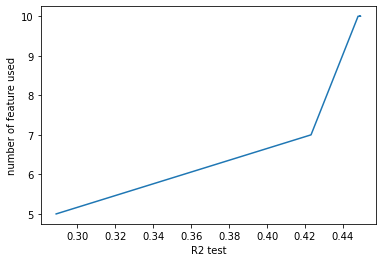

In [20]:
import matplotlib.pyplot as plt
plt.plot(rtest,nf)
plt.xlabel('R2 test')
plt.ylabel('number of feature used')

canclution = best alpha is 0.1 with 10 feature

## Regularization parameter

In [21]:
from sklearn.model_selection import cross_val_score 
from sklearn.linear_model import Lasso

ls=Lasso(alpha=0.1,random_state=3004)
scores = cross_val_score(ls, X_train, y_train, cv=5) #why only train set not whole X and y



print(scores.mean())



#print(ls.score(X_train_scaled,y_train))

0.47841118448021314
0.3590455321852213


C:\Users\kishan kalariya\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:529: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 1711.2876194403216, tolerance: 50.698236363636376
  model = cd_fast.enet_coordinate_descent(
C:\Users\kishan kalariya\anaconda3\lib\site-packages\sklearn\linear_model\_coordinate_descent.py:529: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 5360.087304851098, tolerance: 54.316804494382026
  model = cd_fast.enet_coordinate_descent(


## Task 11

In [22]:
# task(a) split train set into train set proper and calibration set

X_train_pr, X_valid, y_train_pr, y_valid = train_test_split(X_train,y_train,test_size=0.299, random_state=3004)

print("Sizes of train_pr, calibration set, and test sets:",X_train_pr.shape[0], X_valid.shape[0], X_test.shape[0])

Sizes of train_pr, calibration set, and test sets: 232 99 111


In [23]:
# task(b)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaler.fit(X_train_pr)

StandardScaler()

In [24]:
X_train_pr_scaled= scaler.transform(X_train_pr)
X_valid_scaled= scaler.transform(X_valid)


In [25]:
# nonconfurmity measure

In [26]:
## last task 11 (c)

In [27]:
from sklearn.linear_model import Lasso
ls=Lasso().fit(X_train_pr_scaled, y_train_pr)




In [28]:
y_hat= ls.predict(X_valid_scaled)

In [29]:
y_hat = y_hat.reshape(99,1)

In [30]:
print(y_hat.shape)
print( y_valid.shape)

(99, 1)
(99, 1)


C:\Users\kishan kalariya\anaconda3\lib\site-packages\seaborn\distributions.py:2551: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:ylabel='Density'>

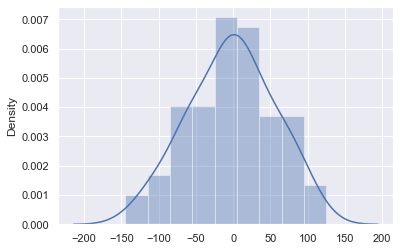

In [31]:
# extra EDA
import  seaborn as sns
sns.set()
sns.distplot( y_valid - y_hat)


In [32]:
alpha_gen = abs(y_valid - y_hat)

In [33]:
alpha=alpha_gen.sort_values(by=['Y'],)


In [34]:
A = alpha.reset_index(drop=True)

In [35]:
#for significance level 5%

k=(1-0.05)*(len(y_valid)+1)



In [36]:
k

95.0

In [37]:
c=A.iloc[95]

In [38]:
c

Y    115.675887
Name: 95, dtype: float64

In [39]:
interval1 = y_hat- 115.67

In [40]:
interval2 = y_hat+ 115.67

In [41]:
#for significance level 20%

k=(1-0.2)*(len(y_valid)+1)

In [42]:
k

80.0

In [43]:
c=A.iloc[80]

In [44]:
c

Y    76.602863
Name: 80, dtype: float64

In [45]:
interval1 = y_hat- 76.60

In [46]:
interval2 = y_hat+ 76.60